In [2]:
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np


def load_and_split(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def fetch_openml_numeric(name, target):
    ds = fetch_openml(name, as_frame=True)
    X = ds.data
    y = ds.target.astype(float)

    # оставляем только числовые признаки
    X = X.select_dtypes(include=[np.number])

    return X.values, y.values


def fetch_openml_numeric_by_id(data_id):
    ds = fetch_openml(data_id=data_id, as_frame=True)
    X = ds.data.select_dtypes(include=[np.number])
    y = ds.target.astype(float)
    return X.values, y.values

In [3]:
# This cell defines a function that trains CatBoost models over a grid of learning rates
# and plots test R2 and number of trees vs learning rate on a single plot with dual y-axes.

import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from tqdm import tqdm


def run_catboost_lr_sweep(name, value, random_seed=42):
    """
    Parameters
    ----------
    name : str
        Experiment name (used for plot title).
    value : tuple
        (X_train, X_val, X_test, y_train, y_val, y_test)
    random_seed : int
        Random seed for CatBoost.

    Returns
    -------
    results : list of dict
        Each dict contains: lr, best_iter, test_r2
    """
    X_train, X_val, X_test, y_train, y_val, y_test = value

    # learning rate grid: 1e-3 to 10 with multiplier 3
    lrs = [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1]  #

    results = []

    for lr in tqdm(lrs):
        model = CatBoostRegressor(
            iterations=100_000,
            learning_rate=lr,
            loss_function="RMSE",
            eval_metric="R2",
            random_seed=random_seed,
            verbose=False,
            early_stopping_rounds=200,
        )

        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

        best_iter = model.get_best_iteration()
        preds = model.predict(X_test)
        test_r2 = r2_score(y_test, preds)

        results.append({"lr": lr, "best_iter": best_iter, "test_r2": test_r2})

    # ---- plotting ----
    lrs_arr = np.array([r["lr"] for r in results])
    best_iters = np.array([r["best_iter"] for r in results])
    test_r2s = np.array([r["test_r2"] for r in results])

    fig, ax1 = plt.subplots()

    ax1.set_xscale("log")
    ax1.set_xlabel("learning rate (log scale)")
    ax1.set_ylabel("test R2")
    ax1.plot(lrs_arr, test_r2s, marker="o", alpha=0.7)

    ax2 = ax1.twinx()
    ax2.set_ylabel("number of trees (best iteration)")
    ax2.plot(lrs_arr, best_iters + 1, marker="s", color="r", alpha=0.7)

    plt.title(f"LR sweep: test R2 and trees vs learning rate\n{name}")
    plt.tight_layout()
    plt.show()

    return results


# The function is now available for use in the session.

100%|██████████| 7/7 [2:55:58<00:00, 1508.37s/it]  


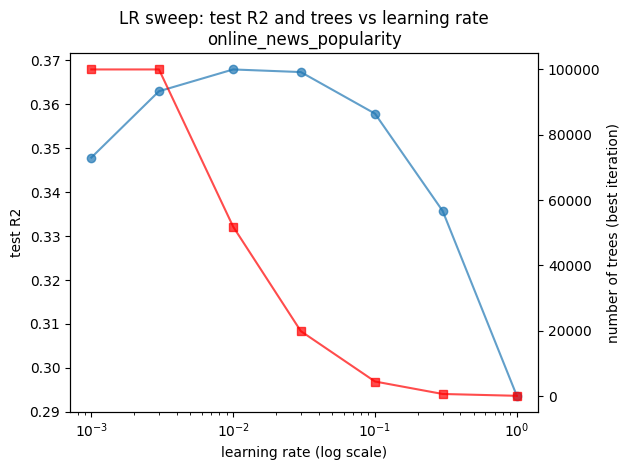

In [3]:
X, y = fetch_openml_numeric_by_id(42705)
results = run_catboost_lr_sweep(
    "online_news_popularity",
    load_and_split(X, y),
)

In [ ]:
import copy

X, y = fetch_openml_numeric_by_id(42705)
X_train, X_val, X_test, y_train, y_val, y_test = copy.deepcopy(load_and_split(X, y))

model = CatBoostRegressor(
    iterations=100_000,
    learning_rate=1e-2,
    loss_function="RMSE",
    eval_metric="R2",
    verbose=False,
    early_stopping_rounds=200,
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

y_train = model.predict(y_train)
y_val = model.predict(y_val)

run_catboost_lr_sweep(
    "online_news_popularity (distillation)",
    (X_train, X_val, X_test, y_train, y_val, y_test),
)

In [4]:
results

[{'lr': 0.001, 'best_iter': 99999, 'test_r2': 0.3478702580640227},
 {'lr': 0.003, 'best_iter': 99999, 'test_r2': 0.36297436563712904},
 {'lr': 0.01, 'best_iter': 51861, 'test_r2': 0.3679343363214036},
 {'lr': 0.03, 'best_iter': 19873, 'test_r2': 0.3673396659117957},
 {'lr': 0.1, 'best_iter': 4451, 'test_r2': 0.3578795389868298},
 {'lr': 0.3, 'best_iter': 631, 'test_r2': 0.3357301103917336},
 {'lr': 1, 'best_iter': 72, 'test_r2': 0.29365478923057353}]

100%|██████████| 7/7 [07:36<00:00, 65.21s/it] 


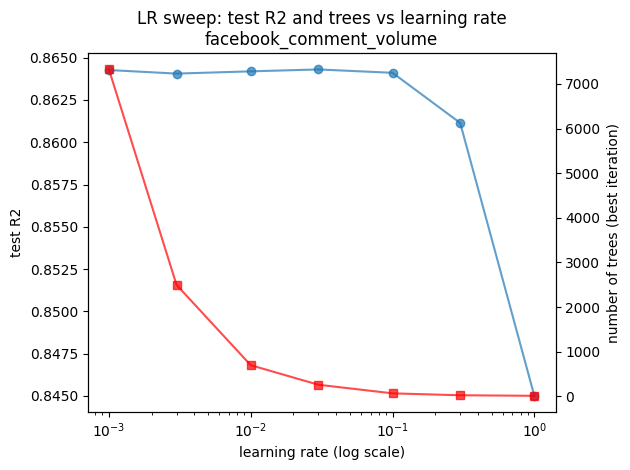

In [5]:
# 4. Facebook Comment Volume
# ~50k samples
X, y = fetch_openml_numeric_by_id(4549)
res2 = run_catboost_lr_sweep(
    "facebook_comment_volume",
    load_and_split(X, y),
)